
---

# ***`Plotting Gradiant Desecent Animations`***

---

#### **Import Libraries**

In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.animation import FuncAnimation

from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression


#### **Make a Regression Dataset**

In [2]:
X,y = make_regression(
    n_samples=100, 
    n_features=1, 
    n_informative=1, 
    n_targets=1,
    noise=20,
    random_state=13,
)


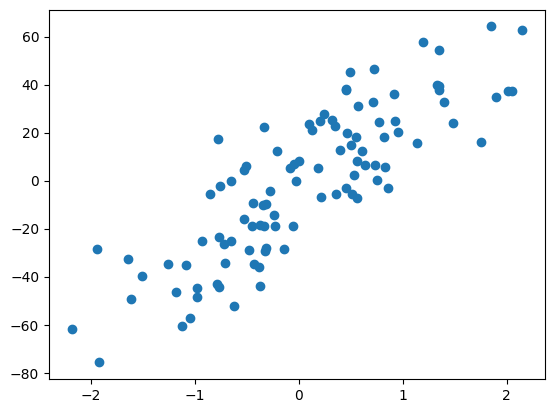

In [ ]:
# plot the data
plt.scatter(X,y)
plt.show()

#### **Define a Simple Gradient Gescent Algorithm**

- This code implements a simple gradient descent algorithm to optimize the parameters of a linear regression model over a specified number of epochs, tracking the values of the intercept, slope, and cost at each iteration.

In [4]:
b = -520  # Initial intercept
m = 600   # Initial slope
lr = 0.001  # Learning rate
all_b = []  # List to store intercept values over epochs
all_m = []  # List to store slope values over epochs
all_cost = []  # List to store cost values over epochs

epochs = 30  # Number of iterations for gradient descent

# Gradient descent loop
for i in range(epochs):
    slope_b = 0  # Initialize slope for intercept
    slope_m = 0  # Initialize slope for slope
    cost = 0     # Initialize cost

    # Loop through each data point
    for j in range(X.shape[0]):
        # Calculate gradients
        slope_b = slope_b - 2 * (y[j] - (m * X[j]) - b)
        slope_m = slope_m - 2 * (y[j] - (m * X[j]) - b) * X[j]
        cost = cost + (y[j] - m * X[j] - b) ** 2  # Accumulate cost

    # Update parameters using gradients
    b = b - (lr * slope_b)
    m = m - (lr * slope_m)
    
    # Store updated values
    all_b.append(b)
    all_m.append(m)
    all_cost.append(cost)

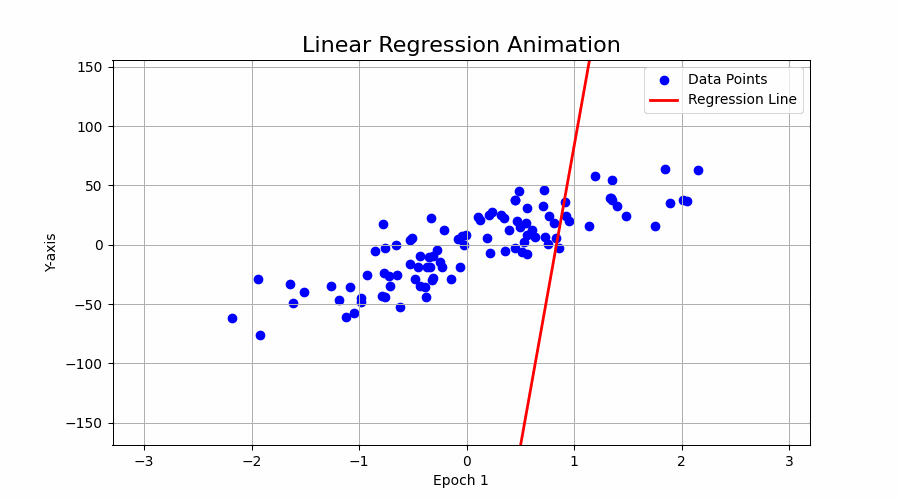

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image

# Create a figure and axis for the plot
fig, ax = plt.subplots(figsize=(9, 5))

# Generate x values for the line to be plotted
x_i = np.arange(-3, 3, 0.1)  # Range of x values from -3 to 3 with a step of 0.1
y_i = x_i * (-27) - 150      # Calculate corresponding y values (not used in the plot)

# Scatter plot of the data points (X, y)
ax.scatter(X, y, label='Data Points', color='blue')  # Scatter plot for original data

# Initial line plot for the regression line
line, = ax.plot(x_i, x_i * 50 - 4, 'r-', linewidth=2, label='Regression Line')  # Initial line

# Set title and labels
ax.set_title('Linear Regression Animation', fontsize=16)  # Title for the plot
ax.set_xlabel('X-axis')  # Label for the x-axis
ax.set_ylabel('Y-axis')  # Label for the y-axis

# Add grid in the background
ax.grid(True)  # Enable grid

# Function to update the plot for each frame of the animation
def update(i):
    label = 'Epoch {0}'.format(i + 1)  # Create a label for the current epoch
    line.set_ydata(x_i * all_m[i] + all_b[i])  # Update the line with current parameters
    ax.set_xlabel(label)  # Update x-axis label to show current epoch
    ax.legend()  # Show legend to identify data points and regression line

# Create an animation that updates the plot at each frame
anim = FuncAnimation(fig, update, repeat=True, frames=len(all_b), interval=500)  # Animate over epochs

# Save the animation as a GIF
anim.save('linear_regression_animation.gif', writer=PillowWriter(fps=2))

# Close the figure to avoid displaying it
plt.close(fig)

# Display the GIF in Jupyter Notebook
Image(filename='linear_regression_animation.gif')

---